In [2]:
import fastf1 as f1
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
import pandas as pd
import datetime as dt
import seaborn as sns
from fastf1 import plotting
from fastf1 import utils
from matplotlib import colors as mcolors
from matplotlib.ticker import FuncFormatter


In [5]:
class F1Analyzer:
    def __init__(self, year, grand_prix, session_type):
        self.year = year
        self.grand_prix = grand_prix
        self.session_type = session_type
        self.session = f1.get_session(year, grand_prix, session_type)
        self.session.load()
        
        
    def get_clean_laps(self, driver):
        laps = self.session.laps.pick_driver(driver)
    # .isna() vérifie si la case est vide (donc pas d'arrêt aux stands)
        clean_1_laps = laps.loc[
        (laps["PitInTime"].isna()) & 
        (laps["PitOutTime"].isna()) & 
        (laps["TrackStatus"] == "1")
        ].copy()
        full_range = range(1, self.session.total_laps + 1)
        clean_1_laps = clean_1_laps.set_index('LapNumber').reindex(full_range).reset_index()
        return clean_1_laps
    def audit_data_cleaning(self, driver):
    # 1. Données brutes (Total)
        raw_laps = self.session.laps.pick_driver(driver)
        total_raw = len(raw_laps)

    # 2. Après filtre "Physique" (Stands + Safety Car)
        phys_clean = self.get_clean_laps(driver)
        total_phys = len(phys_clean)
        lost_phys = total_raw - total_phys

    # 3. Après filtre "Statistique" (IQR)
        very_clean = self.get_clean_race_pace_laps(driver)
        total_very = len(very_clean)
        lost_iqr = total_phys - total_very

    # Affichage du rapport
        print(f"--- Audit de Nettoyage pour {driver} ---")
        print(f"Tours totaux en session : {total_raw}")
        print(f"Tours perdus (Stands/Drapeaux) : {lost_phys} ({(lost_phys/total_raw)*100:.1f}%)")
        print(f"Tours perdus (IQR/Anomalies) : {lost_iqr} ({(lost_iqr/total_phys)*100:.1f}%)")
        print(f"Tours restants pour l'analyse : {total_very}")
        print("-" * 40)

        return total_raw, total_phys, total_very
    
    
    def get_clean_race_pace_laps(self,driver):
        Laps=self.get_clean_laps(driver)
        series=Laps["LapTime"].dt.total_seconds()
        Q1=series.quantile(0.25)
        Q3=series.quantile(0.75)
        IQR=Q3-Q1
        lower_bound=Q1-1.5*IQR
        upper_bound=Q3+1.5*IQR
        clean_2_laps=Laps[(series>=lower_bound)&(series<=upper_bound)]
        full_range = range(1, self.session.total_laps + 1)
        clean_2_laps = clean_2_laps.set_index('LapNumber').reindex(full_range).reset_index()
        return clean_2_laps
    
    def format_laptime(self, seconds, pos):
        minutes = int(seconds // 60)
        remainder = seconds % 60
        return f"{minutes}:{remainder:06.3f}"

    def plot_drivers_pace(self, session, driver_list,very_clean=False):
        fig, ax = plt.subplots(figsize=(12, 7))

        # Dictionnaire pour suivre les couleurs déjà utilisées
        used_colors = {}

        for driver in driver_list:
            if(very_clean):
                laps = self.get_clean_race_pace_laps(driver)
            else:
                laps=self.get_clean_laps(driver)
            if laps.empty:
                continue

            x = laps["LapNumber"]
            y = laps["LapTime"].dt.total_seconds()

            # --- GESTION INTELLIGENTE DE LA COULEUR ---
            try:
                base_color = plotting.get_driver_color(driver, session=session)
            except Exception:
                base_color = "#FFFFFF"

            # Si la couleur a déjà été utilisée (ex: LEC et SAI), on modifie la deuxième
            if base_color in used_colors.values():
                rgb = mcolors.to_rgb(base_color)
                color = mcolors.to_hex([min(1, c + 0.4) for c in rgb])
                linestyle = "--"  # Pointillés pour plus de clarté
            else:
                color = base_color
                linestyle = "-"
                used_colors[driver] = base_color

            # Tracé avec les nouveaux paramètres
            ax.plot(
                x,
                y,
                color=color,
                label=driver,
                linestyle=linestyle,
                linewidth=2,
                marker="o",
                markersize=3,
                alpha=0.8,
            )

        # Formatage de l'axe Y
        ax.yaxis.set_major_formatter(FuncFormatter(self.format_laptime))

        # Esthétique
        title = f"Race Pace Analysis: {session.event['EventName']} {session.event.year}"
        ax.set_title(title, fontsize=15, pad=20)
        ax.set_xlabel("Tour n°", fontsize=12)
        ax.set_ylabel("Temps au tour", fontsize=12)
        ax.legend(loc="upper right", bbox_to_anchor=(1.15, 1))
        ax.grid(visible=True, linestyle=":", alpha=0.5)

        plt.tight_layout()
        return fig, ax
    
    
        

core           INFO 	Loading data for Italian Grand Prix - Race [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['16', '81', '4', '55', '44', '1', '63', '11', '23', '20', '14', '43', '3', '31', '10', '77', '27', '24', '18', '22']
C:\Users\user\AppData\Roaming\Python\Python313\site-packages\

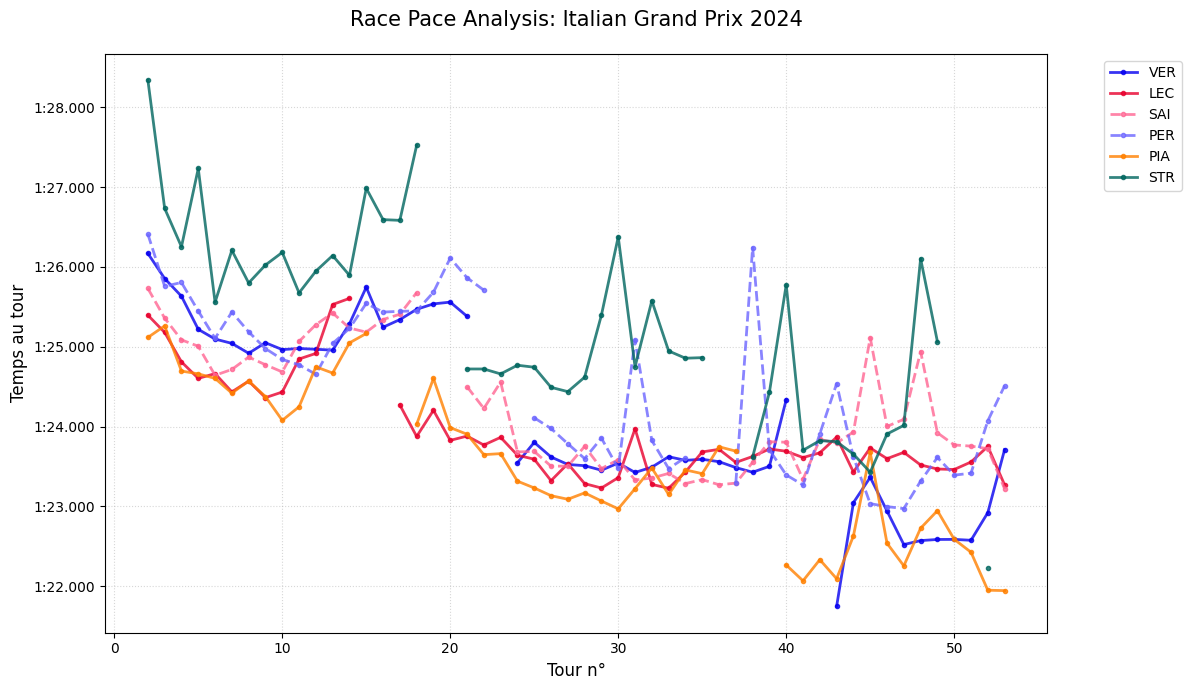

C:\Users\user\AppData\Roaming\Python\Python313\site-packages\fastf1\core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
C:\Users\user\AppData\Roaming\Python\Python313\site-packages\fastf1\core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
C:\Users\user\AppData\Roaming\Python\Python313\site-packages\fastf1\core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
C:\Users\user\AppData\Roaming\Python\Python313\site-packages\fastf1\core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated a

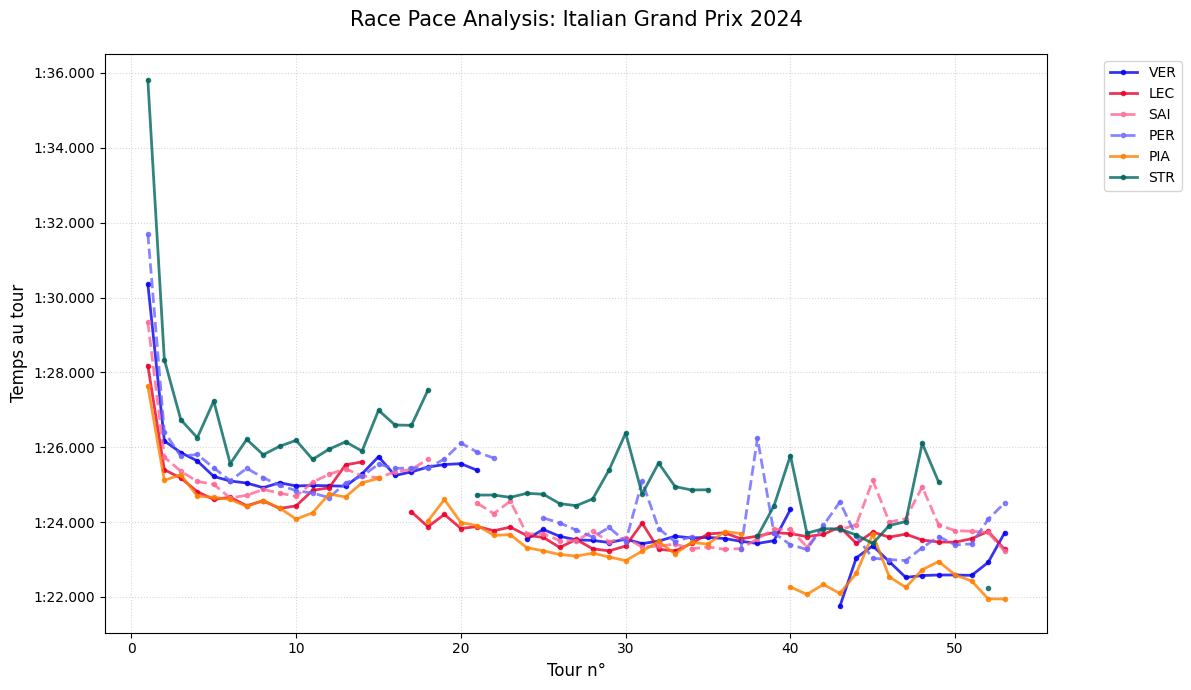

In [33]:
analyzing_monza=F1Analyzer(2024, 'Monza', 'R')
fig, ax=analyzing_monza.plot_drivers_pace(analyzing_monza.session, ['VER', 'LEC', 'SAI', 'PER','PIA','STR'],very_clean=True)
plt.show()
fig,ax=analyzing_monza.plot_drivers_pace(analyzing_monza.session, ['VER', 'LEC', 'SAI', 'PER','PIA','STR'],very_clean=False)
plt.show()

In [37]:
analyzing_monza.get_clean_laps('VER').isna.sum()


C:\Users\user\AppData\Roaming\Python\Python313\site-packages\fastf1\core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


AttributeError: 'function' object has no attribute 'sum'